## LeNet-5 CIA Test 1
**Marks:15**

### Instructions

- Correct the errors without completely rewriting the program.
- Execute the corrected notebook successfully.

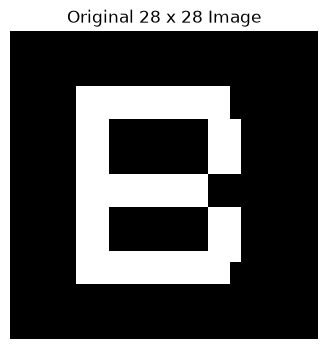

Minimum: 0.0
Maximum: 65025.0
After padding: (32, 32)


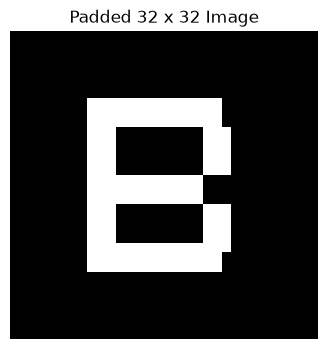

CNN input shape: (32, 32, 1)
Layer 1 shape: (None, 10, 10, 6)
Layer 2 shape: (None, 4, 4, 8)
Layer 3 shape: (None, 480)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C1 (Conv2D)                     │ (None, 30, 30, 6)      │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S2 (AveragePooling2D)           │ (None, 10, 10, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C3 (Conv2D)                     │ (None, 8, 8, 8)        │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S4 (AveragePooling2D)           │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C5 (Conv2D)                     │ (None, 2, 2, 120)      │         8,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 480)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F6 (Dense)                      │ (None, 84)             │        40,404 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,749 (194.33 KB)

 Trainable params: 49,749 (194.33 KB)

 Non-trainable params: 0 (0.00 B)

W0000 00:00:1791176184.972358 3655787 op_kernel.cc:1858] OP_REQUIRES failed at conv_ops_impl.h:668 : INVALID_ARGUMENT: Computed output size would be negative: -1 [input_size: 1, effective_filter_size: 3, stride: 1]
W0000 00:00:1791176184.972373 3655787 local_rendezvous.cc:412] Local rendezvous is aborting with status: INVALID_ARGUMENT: Computed output size would be negative: -1 [input_size: 1, effective_filter_size: 3, stride: 1]


InvalidArgumentError: Exception encountered when calling Conv2D.call().

[1m{{function_node __wrapped__Conv2D_device_/job:localhost/replica:0/task:0/device:CPU:0}} Computed output size would be negative: -1 [input_size: 1, effective_filter_size: 3, stride: 1] [Op:Conv2D][0m

Arguments received by Conv2D.call():
  • inputs=tf.Tensor(shape=(32, 32, 1, 1), dtype=float32)

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Create a single 28 x 28 grayscale image
image = np.zeros((28, 28), dtype=np.float32)
image[5:23, 6:9] = 255
image[5:8, 9:20] = 255
image[13:16, 9:18] = 255
image[20:23, 9:20] = 255
image[8:13, 18:21] = 255
image[16:21, 18:21] = 255

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title("Original 28 x 28 Image")
plt.axis("off")
plt.show()

# Normalize
image = image * 255.0
print("Minimum:", image.min())
print("Maximum:", image.max())

# Pad 28 x 28 to 32 x 32
image = np.pad(image, ((2, 2), (2, 2)), mode="constant", constant_values=0)
print("After padding:", image.shape)

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title("Padded 32 x 32 Image")
plt.axis("off")
plt.show()

# Add batch and channel dimensions
image = image.reshape(32, 32, 1)
print("CNN input shape:", image.shape)

# LeNet-5 style model
inputs = tf.keras.Input(shape=(32, 32, 1))

x = tf.keras.layers.Conv2D(6, kernel_size=(3, 3), activation="relu", name="C1")(inputs)
x = tf.keras.layers.AveragePooling2D(pool_size=(3, 3), name="S2")(x)
print("Layer 1 shape:", x.shape)
x = tf.keras.layers.Conv2D(8, kernel_size=(3, 3), activation="relu", name="C3")(x)
x = tf.keras.layers.AveragePooling2D(pool_size=(2, 2), name="S4")(x)
print("Layer 2 shape:", x.shape)
x = tf.keras.layers.Conv2D(120, kernel_size=(3, 3), activation="relu", name="C5")(x)
x = tf.keras.layers.Flatten(name="Flatten")(x)
print("Layer 3 shape:", x.shape)
features = tf.keras.layers.Dense(84, activation="relu", name="F6")(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="Output")(features)

model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.summary()

# Forward pass
prediction = model(image, training=False)
print("Output shape:", prediction.shape)
print("Predicted class:", np.argmax(prediction[0]))

# Extract C1 feature map
c1_model = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer("C3").output
)
c1_maps = c1_model(image, training=False)

print("C1 feature map shape:", c1_maps.shape)

plt.figure(figsize=(5, 4))
plt.imshow(c1_maps[0, :, :, 0], cmap="gray")
plt.title("LeNet-5 C1 Feature Map")
plt.axis("off")
plt.show()
